# Four-band in Bernal bilayer graphene (Hartree-Fock SFC)

This notebook extends `01_noninteracting_initialization.ipynb`. It retains **all four bands per spin and valley**, constructs the Hartree and Fock matrices, and iterates at fixed carrier density. It uses the same `bernal_initializer.py` Hamiltonian and filling routines.

**Model used here.** The state is homogeneous and diagonal in spin and valley. There are four $4\times4$ blocks, equivalent to a block-diagonal $16\times16$ internal matrix. Spin and valley **populations can differ**. Off-diagonal spin/valley coherences and spatially modulated states are outside this ansatz. The interaction is the component-independent, dual-gate-screened Coulomb interaction. 

The full calculation is at $T=0$.

## 1. Notation and units

We use the notation of the written SCF cycle. In particular,

$$P_{\lambda\lambda'}(\mathbf k)=\langle c^\dagger_{\mathbf k\lambda'}c_{\mathbf k\lambda}\rangle,
\qquad P_{\mathrm{in}}^{(0)}=\rho^{(0)},\qquad \lambda=(\tau,s,\sigma).$$

| Symbol | Meaning | Python name |
|:--|:--|:--|
| $P_{\mathrm{in}}^{(j)}$, $P_{\mathrm{out}}^{(j)}$ | Input and output of iteration $j$ | `P_in`, `P_out` |
| $P_{\mathrm{ref}}$ | Fixed, neutral, noninteracting reference at $T=0$ | `problem.P_ref` |
| $h_0$, $h_{\mathrm{HF}}$ | Noninteracting and Hartree–Fock matrices | `problem.h0`, `h_HF` |
| $\Sigma_H$, $\Sigma_F$ | Hartree and Fock self-energies | `problem.sigma_H(P)`, `problem.sigma_F(P)` |
| $w_{\mathbf k}$ | Weights representing $d^2k/(2\pi)^2$ | `grid.weights_cm2`, `problem.weights_A2` |
| $\alpha$, $\epsilon_P$, $\epsilon_E$ | Mixing and convergence tolerances | Fields of `SCFSettings` |

Block-array order is `(valley, spin, k, sublattice, sublattice)`. Valleys are $(K,K')$, spins $(\uparrow,\downarrow)$, and sublattices **$(A_1,B_1,A_2,B_2)$**. Eigenvectors are columns. 

The module uses energies in **eV**, momenta in **Å$^{-1}$**, and integration weights in **Å$^{-2}$**. Carrier densities are in cm$^{-2}$:
$$w_{\mathbf k}[\mathrm{Å}^{-2}]=10^{-16}w_{\mathbf k}[\mathrm{cm}^{-2}].$$


In [2]:
%pip install threadpoolctl

Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Users\perez\OneDrive\Documentos\RICE\ROTATIONS\si\BG_Hartree-Fock-main\.venv\Scripts\python.exe -m pip install --upgrade pip' command.


In [1]:
print("Python is responding", flush=True)

import numpy
print("NumPy loaded", flush=True)

import matplotlib.pyplot
print("Matplotlib loaded", flush=True)

import scipy
print("SciPy loaded", flush=True)

import threadpoolctl
print("threadpoolctl loaded", flush=True)

import bernal_initializer
print("Initializer loaded", flush=True)

import bernal_hf
print("HF module loaded", flush=True)

Python is responding
NumPy loaded
Matplotlib loaded
SciPy loaded
threadpoolctl loaded
Initializer loaded
HF module loaded


In [3]:
import json
from dataclasses import asdict, replace
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from threadpoolctl import threadpool_limits

from bernal_initializer import Parameters, make_hexagonal_grid, initialize, hamiltonian
from bernal_hf import (
    InteractionParameters, SCFSettings, HFProblem,
    run_scf, best_converged, full_internal_matrix, EV_A2_TO_MEV_NM2,
)

plt.rcParams.update({
    "figure.dpi": 110, "font.size": 11,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.labelsize": 12, "legend.frameon": False,
})
output_dir = Path("hf_outputs")
output_dir.mkdir(exist_ok=True)

## 2. Choose the model parameters and mesh

`D_eV` is the **layer energy bias**, entering the diagonal terms as $\pm D/2$ in the eq. (2) matrix. 

We use $D=50$ meV, $n_{\mathrm{carrier}}=-5\times10^{11}$ cm$^{-2}$, $\epsilon_r=20$, and gate distance $d_{\mathrm{sc}}=30$ nm. The hopping parameters are the same as in your initializer. Negative carrier density means hole doping relative to neutrality.

The default `shells=8` mesh has 217 points per valley and this is intended for a quick first run. The continuum cutoff remains $\Lambda a=0.12$. Exchange uses a dense $N_k\times N_k$ kernel, so increasing the mesh increases memory approximately as $N_k^2$. Mesh and cutoff convergence are separate from convergence of the SCF iteration.

In [4]:
parameters = Parameters(D_eV=0.050)
interaction = InteractionParameters(
    epsilon_r=20.0,
    d_sc_nm=30.0,
    strength=1.0,
)
settings = SCFSettings(
    target_density_cm2=-5e11,
    temperature_K=0.0,
    alpha=0.25,
    epsilon_P=1e-6,
    epsilon_E_eV_A2=1e-11,
    max_iterations=500,
)
grid = make_hexagonal_grid(
    shells=8,
    cutoff_times_a=0.12,
    a_angstrom=parameters.a_angstrom,
)
problem = HFProblem(parameters, grid, interaction)

print("Number of momenta per valley:", len(grid.k_Ainv))
print("h0 / P block-array shape:", problem.h0.shape)
print("Stored exchange kernel: %.2f MiB" % (problem.kernel_eV.nbytes / 2**20))
print("Band parameters:", asdict(parameters))
print("Interaction parameters:", asdict(interaction))
print("Temperature:", settings.temperature_K, "K")

Number of momenta per valley: 217
h0 / P block-array shape: (2, 2, 217, 4, 4)
Stored exchange kernel: 0.36 MiB
Band parameters: {'D_eV': 0.05, 'a_angstrom': 2.46, 't0_eV': 2.61, 't1_eV': 0.361, 't3_eV': 0.283, 't4_eV': 0.138, 'delta_prime_eV': 0.015}
Interaction parameters: {'epsilon_r': 20.0, 'd_sc_nm': 30.0, 'strength': 1.0}
Temperature: 0.0 K


## 3. Fix the interaction and reference convention

For the component-independent interaction, each flavor block has

$$\Sigma_H[P]=\widetilde V(0)n_{\mathrm{abs}}[P]\,I_4,
\qquad n_{\mathrm{abs}}[P]=\sum_{\tau,s,\mathbf k}w_{\mathbf k}\operatorname{tr}P_{\tau s}(\mathbf k),$$
$$\Sigma_{F,\tau s}[P](\mathbf k)=-\sum_{\mathbf k'}w_{\mathbf k'}\widetilde V(|\mathbf k-\mathbf k'|)P_{\tau s}(\mathbf k').$$

Here
$$\widetilde V(q)=\frac{e^2}{2\epsilon_0\epsilon_rq}\tanh(qd_{\mathrm{sc}}),
\qquad \widetilde V(0)=\frac{e^2d_{\mathrm{sc}}}{2\epsilon_0\epsilon_r}.$$
The $q=0$ limit is finite and is included in the exchange-kernel diagonal. Its units in the code are eV Å$^2$.

The fixed reference prescription used in this notebook is
$$\Sigma[P]=\Sigma_H[P]+\Sigma_F[P],\qquad
h_{\mathrm{ref}}=\frac12\Sigma[P_{\mathrm{ref}}],\qquad
h_{\mathrm{HF}}[P]=h_0-h_{\mathrm{ref}}+\Sigma[P].$$

$P_{\mathrm{ref}}$ is computed once at neutrality for the same $h_0$, mesh, and cutoff. It is distinct from the **doped initial state** $P_{\mathrm{in}}^{(0)}$. The half-reference subtraction is a fixed one-body term. It is not the full subtraction $\Sigma[P-P_{\mathrm{ref}}]$ and is not the scalar HF double-counting correction.

The uniform Hartree term is retained consistently in the Hamiltonian and energy. At fixed density it shifts every internal level equally; flavor selection in this model comes from exchange and the band structure. Its absolute shift can be large because $n_{\mathrm{abs}}$ counts all retained occupied states. Band comparisons below therefore use $\varepsilon-\mu$.

In [5]:
print("V(0): %.6f eV Å²" % problem.V0_eV_A2)
print("Reference carrier density: %.3e cm^-2" % problem.carrier_density_cm2(problem.P_ref))
print("Reference shape:", problem.P_ref.shape)

# This is the same rho^(0) construction as in the first notebook.
initial = initialize(
    parameters=parameters, grid=grid,
    target_density_cm2=settings.target_density_cm2,
    temperature_K=0.0,
)
P_in_0 = initial.rho0.copy()
print("Initial carrier density: %.8e cm^-2" % problem.carrier_density_cm2(P_in_0))
print("Initial noninteracting mu: %.6f meV" % (1000 * initial.mu_eV))

V(0): 1357.134613 eV Å²
Reference carrier density: -6.564e-02 cm^-2
Reference shape: (2, 2, 217, 4, 4)
Initial carrier density: -5.00000000e+11 cm^-2
Initial noninteracting mu: -25.000000 meV


## 4. Inspect one iteration explicitly

For a given $P_{\mathrm{in}}^{(j)}$, construct $h_{\mathrm{HF}}$, diagonalize every block, and choose **one chemical potential for all momenta, spins, valleys, and four bands**. Filling solves

$$n_{\mathrm{carrier}}=\sum_{\tau,s,\mathbf k} w_{\mathbf k}
\left[\sum_{\nu=1}^4 f_{\tau s\nu}(\mathbf k)-2\right].$$

The $-2$ subtracts the neutral reference count in each four-band flavor block. It is used when reporting **carrier density**, not as an instruction to discard two bands from the density matrix.

At $T=0$, fill levels in increasing energy order. If the requested density ends within a degenerate energy shell on the finite mesh, distribute the remaining occupation equally over that shell. Thus $0\leq f\leq1$ and a partially occupied shell is possible without finite-temperature smearing.

Reconstruct
$$P_{\mathrm{out},\sigma\sigma'}^{(j)}(\mathbf k)=\sum_{\nu=1}^4
f_\nu^{(j)}(\mathbf k)u_{\sigma\nu}^{(j)}(\mathbf k)u_{\sigma'\nu}^{(j)*}(\mathbf k),$$
with the flavor labels suppressed. Then measure the **unmixed** residual and mix:
$$r_j=\max_{\tau,s,\mathbf k,\sigma,\sigma'}\left|
P_{\mathrm{out}}^{(j)}-P_{\mathrm{in}}^{(j)}\right|,
\qquad P_{\mathrm{in}}^{(j+1)}=(1-\alpha)P_{\mathrm{in}}^{(j)}+\alpha P_{\mathrm{out}}^{(j)}.$$

In [6]:
P_in = P_in_0.copy()

# Step 1: build the physical HF matrix from the input density.
Sigma_H = problem.sigma_H(P_in)
Sigma_F = problem.sigma_F(P_in)
h_HF = problem.h0 - problem.h_ref + Sigma_H + Sigma_F

# Steps 2–4: diagonalize, fill globally, and reconstruct P_out.
# fill_hamiltonian calls eigh, fill_occupations, and density_matrix.
iteration = problem.fill_hamiltonian(h_HF, settings)
epsilon = iteration.eigenvalues_eV
u = iteration.eigenvectors
f = iteration.occupations
mu = iteration.mu_eV
P_out = iteration.P_out

# Step 5: measure the residual BEFORE applying damping.
r_0 = np.max(np.abs(P_out - P_in))
P_in_1 = (1 - settings.alpha) * P_in + settings.alpha * P_out

print("First unmixed residual r_0: %.6e" % r_0)
print("Output density: %.8e cm^-2" % problem.carrier_density_cm2(P_out))
print("Mixed input density: %.8e cm^-2" % problem.carrier_density_cm2(P_in_1))

# Inspect the projector sum at one momentum in K, spin up.
iv, isp = 0, 0
ik = np.argmin(np.abs(epsilon[iv, isp, :, 1] - mu))
U = u[iv, isp, ik]
P_manual = sum(f[iv, isp, ik, nu] * np.outer(U[:, nu], U[:, nu].conj())
               for nu in range(4))
print("Manual reconstruction error:", np.max(np.abs(P_manual - P_out[iv, isp, ik])))

First unmixed residual r_0: 6.740708e-01
Output density: -5.00000000e+11 cm^-2
Mixed input density: -5.00000000e+11 cm^-2
Manual reconstruction error: 1.5515838457795457e-17


## 5. Evaluate the total Hartree–Fock energy

The energy density consistent with this Hamiltonian is

$$\mathcal E[P]=\sum_{\tau,s,\mathbf k}w_{\mathbf k}
\operatorname{tr}\!\left[(h_0-h_{\mathrm{ref}})P+\frac12\Sigma[P]P\right].$$

The factor $1/2$ prevents interaction double counting. The fixed one-body term $-h_{\mathrm{ref}}$ has **no additional factor of $1/2$** in this formula. Both $P$ and $\Sigma[P]$ must be evaluated at the same state. A sum of occupied HF eigenvalues by itself is not the total HF energy.

Each iteration records $\mathcal E[P_{\mathrm{out}}^{(j)}]$. Acceptance requires
$$r_j<\epsilon_P,\qquad
\left|\mathcal E[P_{\mathrm{out}}^{(j)}]-\mathcal E[P_{\mathrm{out}}^{(j-1)}]\right|<\epsilon_E.$$
The solver then builds a Hamiltonian from the proposed final state and checks its own SCF residual again. Reaching `max_iterations` is reported as **not converged**. Damped fixed-point iteration need not lower the energy on every step.

In [7]:
E_first = problem.energy_density(P_out)  # Recomputes Sigma at P_out.
print("First output energy density: %.10f meV/nm²" % (E_first * EV_A2_TO_MEV_NM2))
print("Energy-change tolerance: %.2e meV/nm²" % (settings.epsilon_E_eV_A2 * EV_A2_TO_MEV_NM2))

First output energy density: -34.6113588554 meV/nm²
Energy-change tolerance: 1.00e-06 meV/nm²


## 6. Run the complete cycle from several seeds

The symmetric seed is your noninteracting $\rho^{(0)}$. The other seeds are constructed by diagonalizing $h_0+\eta M$ and filling to the **same target density**. This produces a Hermitian density matrix with occupations in $[0,1]$ without clipping arbitrary matrix entries. The seed field is absent from subsequent iterations.

`spin`, `valley`, and `spin_valley` use $M=s_z$, $\tau_z$, and $\tau_zs_z$ (identities in sublattice space). `layer` uses $\operatorname{diag}(1,1,-1,-1)$ in each block; `random` uses reproducible Hermitian perturbations within the allowed flavor blocks. These labels identify the **initial seed**, not a predetermined final phase.

Several seeds can reach equivalent solutions or metastable states. Compare only converged candidates using the same model, reference, density, temperature, mesh, and cutoff. This estimates the lowest energy among the tested states within the restricted ansatz; it does not establish a global ground state.

In [8]:
seed_names = ["symmetric", "spin", "valley", "spin_valley", "layer", "random"]
results = []
for seed in seed_names:
    result = run_scf(
        problem, settings,
        seed=seed, seed_meV=1.0, random_seed=0,
    )
    results.append(result)
    print(f"{seed:12s}  converged={str(result.converged):5s}  "
          f"iterations={len(result.history):3d}  "
          f"residual={result.diagnostics['unmixed_residual']:.2e}  "
          f"time={result.elapsed_s:.2f} s")

best = best_converged(results)
if best is None:
    raise RuntimeError(
        "No candidate converged. Inspect the residuals; try a smaller alpha "
        "or more iterations. Do not rank unconverged energies as solutions."
    )

table = ["| Initial seed | Converged | Iterations | E − lowest [meV/nm²] | Final residual |",
         "|:--|:--:|--:|--:|--:|"]
for r in results:
    delta = (r.energy_eV_A2 - best.energy_eV_A2) * EV_A2_TO_MEV_NM2
    table.append(f"| {r.seed} | {r.converged} | {len(r.history)} | {delta:.8f} | {r.diagnostics['unmixed_residual']:.2e} |")
display(Markdown("\n".join(table)))

equivalent = [r.seed for r in results if r.converged and
              abs(r.energy_eV_A2 - best.energy_eV_A2) < settings.epsilon_E_eV_A2]
print("Selected representative:", best.seed)
print("Candidates within epsilon_E of its energy:", equivalent)

symmetric     converged=True   iterations= 48  residual=1.27e-08  time=0.93 s
spin          converged=True   iterations= 42  residual=1.04e-07  time=0.87 s
valley        converged=True   iterations= 42  residual=1.04e-07  time=0.68 s
spin_valley   converged=True   iterations= 42  residual=1.04e-07  time=0.68 s
layer         converged=True   iterations= 54  residual=7.58e-10  time=0.86 s
random        converged=True   iterations= 81  residual=2.18e-08  time=1.42 s


| Initial seed | Converged | Iterations | E − lowest [meV/nm²] | Final residual |
|:--|:--:|--:|--:|--:|
| symmetric | True | 48 | 0.00297873 | 1.27e-08 |
| spin | True | 42 | 0.00000000 | 1.04e-07 |
| valley | True | 42 | 0.00000000 | 1.04e-07 |
| spin_valley | True | 42 | 0.00000000 | 1.04e-07 |
| layer | True | 54 | 0.00297873 | 7.58e-10 |
| random | True | 81 | 0.00048687 | 2.18e-08 |

Selected representative: spin
Candidates within epsilon_E of its energy: ['spin', 'valley', 'spin_valley']


## 7. Track convergence

All energy curves use the **same** final-energy baseline. The other panels show the unmixed density residual and the change of energy between successive outputs. Dashed horizontal lines mark the requested tolerances. These curves diagnose convergence of the discrete calculation; the small default mesh is not a phase-diagram benchmark.

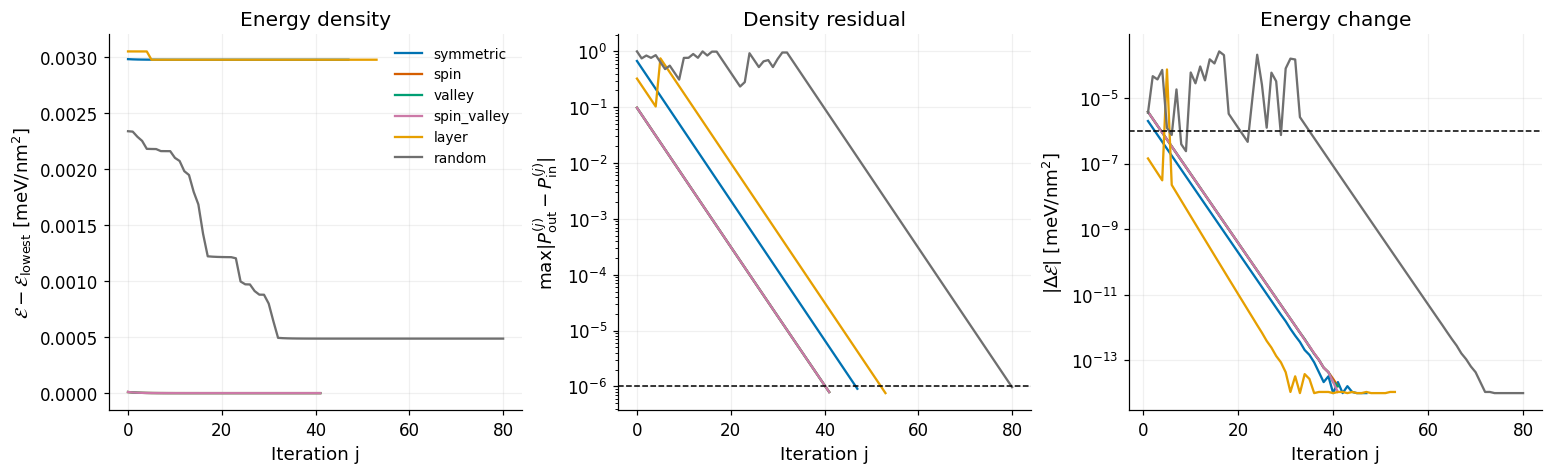

In [9]:
colors = ["#0072B2", "#D55E00", "#009E73", "#CC79A7", "#E69F00", "#6F6F6F"]
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2), layout="constrained")
for r, color in zip(results, colors):
    j = np.array([row["j"] for row in r.history])
    E = np.array([row["energy_eV_A2"] for row in r.history])
    residual = np.array([row["residual"] for row in r.history])
    delta = np.array([np.nan if row["delta_E_eV_A2"] is None else row["delta_E_eV_A2"]
                      for row in r.history])
    axes[0].plot(j, (E - best.energy_eV_A2) * EV_A2_TO_MEV_NM2, color=color, label=r.seed)
    axes[1].semilogy(j, np.maximum(residual, 1e-16), color=color)
    axes[2].semilogy(j, np.maximum(delta * EV_A2_TO_MEV_NM2, 1e-14), color=color)
axes[0].set(ylabel=r"$\mathcal{E}-\mathcal{E}_{\rm lowest}$ [meV/nm$^2$]", title="Energy density")
axes[1].set(ylabel=r"$\max|P_{\rm out}^{(j)}-P_{\rm in}^{(j)}|$", title="Density residual")
axes[2].set(ylabel=r"$|\Delta\mathcal{E}|$ [meV/nm$^2$]", title="Energy change")
axes[1].axhline(settings.epsilon_P, color="black", ls="--", lw=1)
axes[2].axhline(settings.epsilon_E_eV_A2 * EV_A2_TO_MEV_NM2, color="black", ls="--", lw=1)
axes[0].legend(fontsize=9)
for ax in axes:
    ax.set_xlabel("Iteration j")
    ax.grid(alpha=0.18)
fig.savefig(output_dir / "scf_convergence.png", dpi=180)
fig.savefig(output_dir / "scf_convergence.pdf")
plt.show()

## 8. Inspect the final density matrix and flavor densities

$P$ is an occupation matrix, not a trace-one single-particle state. Its trace at a particular momentum counts occupied bands in that flavor block. Only its weighted sum over the mesh is constrained by the target density.

A valid result has small Hermiticity and SCF residual errors and occupation eigenvalues in $[0,1]$ up to roundoff. The commutator $[h_{\mathrm{HF}}[P],P]$ checks that the density is stationary under its own mean-field Hamiltonian. It is a useful diagnostic, but by itself does not establish the correct filling or an energy minimum. Fractional occupations in the final degenerate shell mean **$P^2=P$ is not required** on this finite grid, even at $T=0$.

{
  "unmixed_residual": 1.0370114081257897e-07,
  "commutator_eV": 1.0387591564686716e-08,
  "hermiticity_error": 4.9065389333867974e-18,
  "minimum_occupation": -4.1919510144564005e-16,
  "maximum_occupation": 1.000000000000002,
  "density_error_cm2": 0.0008544921875,
  "idempotency_defect": 0.08679862236124646
}
Total carrier density: -5.0000000000e+11 cm^-2
K up    : -2.03902808e+11 cm^-2
K down  : -4.60971916e+10 cm^-2
K' up   : -2.03902808e+11 cm^-2
K' down : -4.60971916e+10 cm^-2
Full internal shape: (217, 16, 16)
Selected k*a: [-0.0375     -0.01299038]
Each 4x4 block has sublattice order (A1, B1, A2, B2).


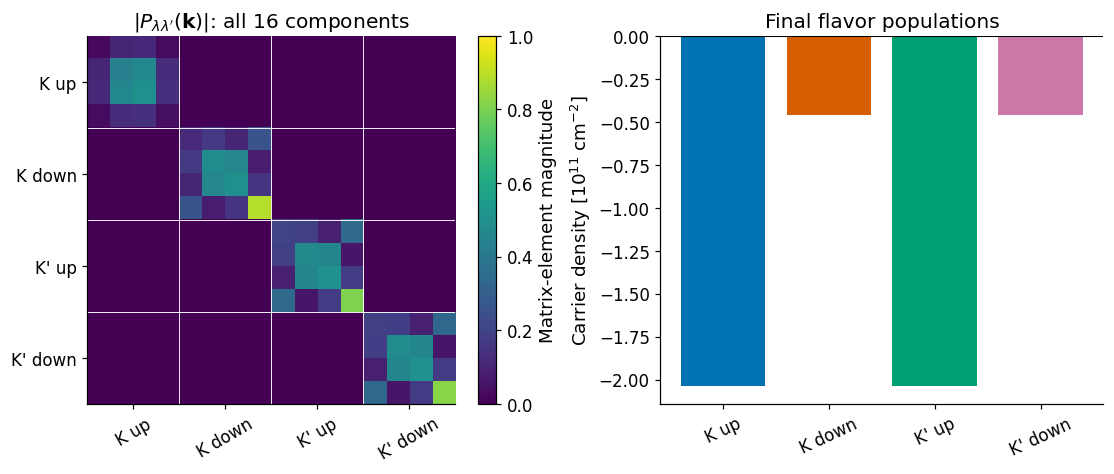

In [ ]:
print(json.dumps(best.diagnostics, indent=2))
print("Total carrier density: %.10e cm^-2" % problem.carrier_density_cm2(best.P))

flavor_labels = ["K up", "K down", "K' up", "K' down"]
densities = problem.density_by_flavor_cm2(best.P).ravel()
for label, density in zip(flavor_labels, densities):
    print(f"{label:8s}: {density: .8e} cm^-2")

# Choose one momentum near mu in the upper valence band, K spin up.
iv, isp = 0, 0
ik = np.argmin(np.abs(best.mapped.eigenvalues_eV[iv, isp, :, 1] - best.mapped.mu_eV))
P_full = full_internal_matrix(best.P)
print("Full internal shape:", P_full.shape)
print("Selected k*a:", grid.k_Ainv[ik] * parameters.a_angstrom)
print("Each 4x4 block has sublattice order (A1, B1, A2, B2).")

fig, axes = plt.subplots(1, 2, figsize=(10, 4.2), layout="constrained")
im = axes[0].imshow(np.abs(P_full[ik]), vmin=0, vmax=1, cmap="viridis", origin="upper")
centers = [1.5, 5.5, 9.5, 13.5]
axes[0].set_xticks(centers, flavor_labels, rotation=30)
axes[0].set_yticks(centers, flavor_labels)
for edge in (3.5, 7.5, 11.5):
    axes[0].axvline(edge, color="white", lw=0.6)
    axes[0].axhline(edge, color="white", lw=0.6)
axes[0].set_title(r"$|P_{\lambda\lambda'}(\mathbf{k})|$: all 16 components")
fig.colorbar(im, ax=axes[0], label="Matrix-element magnitude")
axes[1].bar(flavor_labels, densities / 1e11, color=colors[:4])
axes[1].axhline(0, color="black", lw=0.7)
axes[1].set(ylabel=r"Carrier density [$10^{11}$ cm$^{-2}$]", title="Final flavor populations")
axes[1].tick_params(axis="x", rotation=25)
fig.savefig(output_dir / "density_matrix_and_flavors.png", dpi=180)
plt.show()

## 9. Compare the four noninteracting and HF bands

We evaluate a smooth $k_y=0$ cut around $K$. The Fock sum still uses **the original two-dimensional integration grid and converged $P$**; the plotting cut is not used for filling.

The left panel displays all four bands. The right panel enlarges the central pair. Both models have four bands throughout. Each spectrum is measured relative to **its own chemical potential at the same target density**; this removes the uniform Hartree shift from the visual comparison. The plotted flavor is $K,\uparrow$; change `iv, isp` to inspect another block. $k_x$ here is measured from the selected valley center.

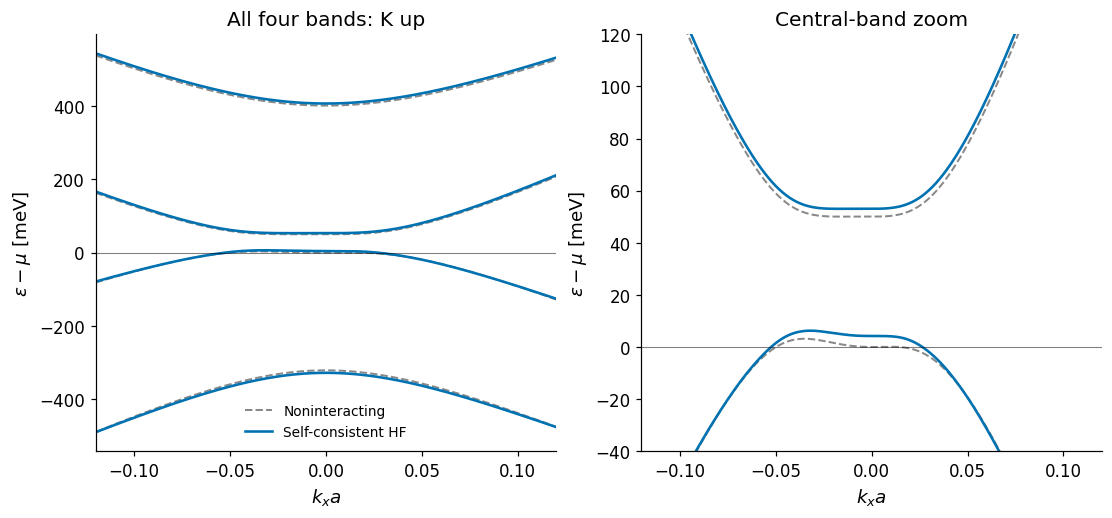

In [ ]:
iv, isp = 0, 0
x = np.linspace(-0.12, 0.12, 401)  # x = k_x*a is dimensionless.
k_line = np.column_stack((x / parameters.a_angstrom, np.zeros_like(x)))
with threadpool_limits(limits=1, user_api="blas"):
    h_line = problem.build_h_HF_at(k_line, best.P)
    E_HF = np.linalg.eigvalsh(h_line[iv, isp])
    E_0 = np.linalg.eigvalsh(hamiltonian(k_line, valley=(+1, -1)[iv], parameters=parameters))
E_HF = 1000 * (E_HF - best.mapped.mu_eV)
E_0 = 1000 * (E_0 - initial.mu_eV)

fig, axes = plt.subplots(1, 2, figsize=(10, 4.6), layout="constrained")
for ax in axes:
    for nu in range(4):
        ax.plot(x, E_0[:, nu], color="#888888", ls="--", lw=1.3,
                label="Noninteracting" if nu == 0 else None)
        ax.plot(x, E_HF[:, nu], color="#0072B2", lw=1.7,
                label="Self-consistent HF" if nu == 0 else None)
    ax.axhline(0, color="black", lw=0.7, alpha=0.5)
    ax.set(xlabel=r"$k_x a$", ylabel=r"$\varepsilon-\mu$ [meV]", xlim=(-0.12, 0.12))
    ax.set_xticks([-0.10, -0.05, 0.0, 0.05, 0.10])
axes[0].set_title("All four bands: " + flavor_labels[2 * iv + isp])
axes[0].legend(fontsize=9)
axes[1].set(title="Central-band zoom", ylim=(-40, 120))
fig.savefig(output_dir / "four_band_hf_comparison.png", dpi=180)
fig.savefig(output_dir / "four_band_hf_comparison.pdf")
plt.show()

## 10. Check the noninteracting limit and save the result

Setting the interaction strength to zero must recover the original initializer at the same density and mesh. This verifies the interface between the old notebook and the SCF cycle. The included test file also checks the weighted exchange sum, the finite $q=0$ value, reference subtraction, and the functional relation $\delta\mathcal E=\sum_{\mathbf k}w_{\mathbf k}\operatorname{tr}(h_{\mathrm{HF}}\,\delta P)$.

In [ ]:
problem_zero = HFProblem(parameters, grid, replace(interaction, strength=0.0))
zero_result = run_scf(problem_zero, settings)
assert zero_result.converged
np.testing.assert_allclose(zero_result.P, initial.rho0, atol=1e-12)
print("Zero-interaction check passed.")

state_path = best.save(output_dir / "example_hf_state.npz", problem)
summary = {
    "scope": "T=0; four-band; homogeneous; spin/valley-diagonal Coulomb HF",
    "parameters": asdict(parameters), "interaction": asdict(interaction),
    "settings": asdict(settings), "Nk_per_valley": len(grid.k_Ainv),
    "selected_representative": best.seed,
    "candidates_within_energy_tolerance": equivalent,
    "results": [r.summary(problem) for r in results],
}
(output_dir / "example_hf_summary.json").write_text(json.dumps(summary, indent=2), encoding="utf-8")
(output_dir / "all_scf_histories.json").write_text(
    json.dumps({r.seed: r.history for r in results}, indent=2), encoding="utf-8")
print("Saved:", state_path)
print("Plots, histories, and the summary are in:", output_dir.resolve())

# To reload later, without executing Python objects from the file:
with np.load(state_path, allow_pickle=False) as saved:
    P_saved = saved["P"]
    metadata = json.loads(saved["metadata_json"].item())
print("Reloaded P shape:", P_saved.shape)

Zero-interaction check passed.
Saved: hf_outputs/example_hf_state.npz
Plots, histories, and the summary are in: /workspace/scratch/28014b6e2376/output/bernal_hf/hf_outputs
Reloaded P shape: (2, 2, 217, 4, 4)


## Sources and implementation choices

- **Band Hamiltonian and parameter set; four-band bilayer HF context:** Koh et al., *Phys. Rev. B* **110**, 245118 (2024), [Appendix A](https://arxiv.org/html/2407.09612v2#A1). The long-range interaction defaults here are $\epsilon_r=20$ and $d_{\mathrm{sc}}=30$ nm. The full paper also contains SOC and Hund interactions, which are additional terms beyond this model.
- **Density-matrix HF decoupling, half-reference prescription, and SCF method:** Koh et al., *Phys. Rev. B* **109**, 035113 (2024), [Appendix B](https://arxiv.org/html/2306.12486v3#A2). That paper’s band model is trilayer; here its HF methodology is combined with the four-band **bilayer** Hamiltonian above.
- **Original initializer:** `bernal_initializer.py`, retaining $(A_1,B_1,A_2,B_2)$, both valleys and both spins, the neutral subtraction of two occupied bands per flavor, and the finite-grid $T=0$ filling prescription.

